#### The main thing of this project is;
### We are building an ML system that predicts whether a customer will leave (Churn = Yes) or stay (No)
* If we know who might leave, we can: Give discounts, Improve service, Call them before they leave

**importing liabraries**

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load dataset**

In [50]:
df = pd.read_csv('Customer-churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [51]:
df.shape

(7043, 21)

In [52]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [54]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**So in this dataset we had seen only one data was null so we have to fill the column**
### Data Cleaning 
**(why? we had seen Totalchanges column has object but it is numeric data and some data had in this df " " some null spaces is their,so we have to clean the column  )**

In [55]:
df['TotalCharges'].dtypes

dtype('O')

In [56]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

**Why errors='coerce'?**
* Converts invalid values → NaN
* Makes column usable for math & ML

In [57]:
df['TotalCharges'].dtypes

dtype('float64')

In [58]:
print(df['TotalCharges'].mean())
df['TotalCharges'].median() # We know if mean > median the data is rightskewed

2283.3004408418656


1397.475

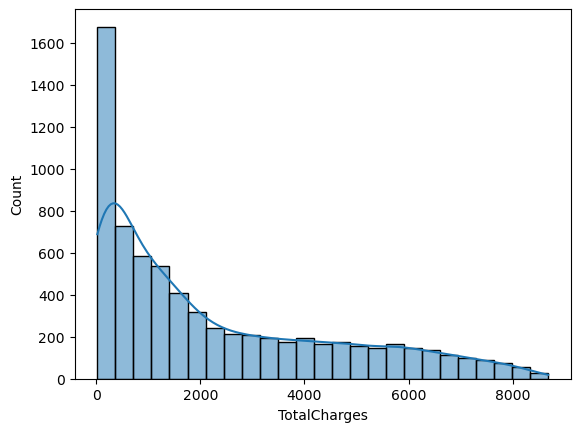

In [59]:
sns.histplot(df['TotalCharges'],kde=True)
plt.show()

In [60]:
df['TotalCharges'].isnull().sum()

np.int64(11)

**Fill missing values** 
* filling missing values with median because it is a rightskewed. and the TotalCharge change to be has Float values because the TotalCharge columns has Object.

In [62]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

### Drop useless column
*Why drop? customerID has no predictive power, ML might learn fake patterns, IDs always removed in real projects

In [63]:
df.drop('customerID',axis=1,inplace = True)

In [64]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,None,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,None,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,None,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,None,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,None,Yes


### Exploratory Data Analysis (EDA)
- Churn distribution
- (Yes/No) Yes-> Customer Has left from Bank. if NO, Customer hasdoes not left.

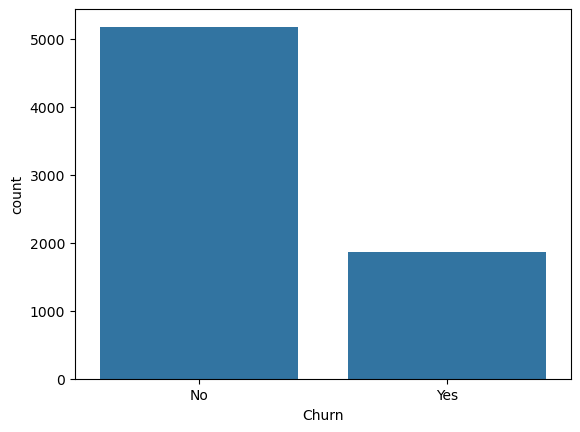

In [65]:
sns.countplot(x='Churn', data=df)
plt.show()

- Tenure -> how long a customer has been with the company or Bank.
- If tenure has 1 means that the customer has been with the company for one month.

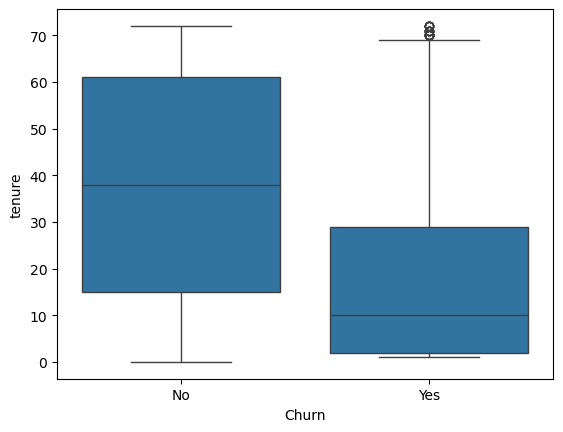

In [66]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

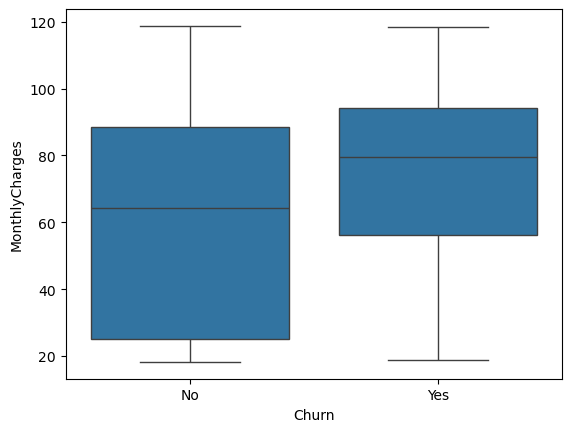

In [67]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [68]:
df.select_dtypes(include = 'object').head(2)

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,None,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,None,No


# Encoding Categorical Variables
- Encoding for ML models only understand numbers :)
- fit( ) → learn the mapping from data(example: Male → 1, Female → 0)
- transform( ) → apply that learned mapping to convert values

In [69]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include = 'object').columns:
    df[col] = le.fit_transform(df[col])

# Feature Scaling
- If numbers have very different ranges and the model uses math distances → SCALE
- Feature	    (   Range)
- tenure	    (   0 → 72)
- MonthlyCharges(   20 → 120)
- TotalCharges	(   0 → 9000)

In [70]:
df[['tenure','MonthlyCharges','TotalCharges']].head(2)

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,0
1,34,56.95,0


In [71]:
from sklearn.preprocessing import StandardScaler # (z=x-meuw/sigma)
scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [72]:
df[['tenure','MonthlyCharges','TotalCharges']].head(2)

,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,0.0
1,0.066327,-0.259629,0.0


# Train-Test Split
**Why split?**
- Train → learn patterns
- Test → simulate real-world unseen customers<br>
**Why stratify=y?**
- it basically we use it for the imbalanced data, it has classification (90%No,10%Yes) then we use it stratify.
- Keeps churn ratio same in train & test
- Prevents fake accuracy

In [76]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [77]:
from sklearn.model_selection import train_test_split
x = df.drop('Churn', axis=1)
y = df['Churn']

In [78]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [79]:
X_test.shape,X_train.shape # for without churn

((2113, 19), (4930, 19))

In [80]:
Y_train.shape,Y_test.shape# with churn

((4930,), (2113,))

# Model Building (Logestic Regression)
- Why Logistic Regression?<br>
Best for binary classification(0/1),Easy to explain to  business ,Strong baseline model

In [81]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

**Prediction**
Probability meaning?<br>
- Output between 0–1
- 0.5 → churn
- Threshold can be changed

In [84]:
Y_pred = model.predict(X_test)
print(Y_pred)
Y_prob = model.predict_proba(X_test)[:,1] # all rows in the second column.
Y_prob

[1 0 1 ... 0 1 0]


array([0.58839028, 0.02979077, 0.75950195, ..., 0.05664106, 0.53870081,
       0.02249102])

**Model Evaluation**<br>
Recall > Accurcy, why?
- Missing a churn customer = revenue loss
- False positve cheaper than False Negative
- ROC = Receiver Operating Characteristic
- AUC = Area Under Curve
- It measures: How well the model separates two classes (Churn vs Not Churn).
- ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) is a tool used to measure how well a classification model can distinguish between two classes (like "Churn" vs. "No Churn") across all possible decision thresholds
- Basically it uses for **Risk-Based Problems** : (Use it for Churn Prediction, Fraud Detection, or Medical Diagnosis)

In [85]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
confusion_matrix(Y_test, Y_pred)

array([[1389,  163],
       [ 256,  305]])

**Train Random Forest**  why?<br>
Because:
- Logistic Regression → linear model
- Random Forest → non-linear model
- Can capture complex patterns
- Often gives better ROC-AUC

In [89]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]
print(classification_report(Y_test, rf_pred))
print("ROC AUC:", roc_auc_score(Y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.62      0.48      0.54       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113

ROC AUC: 0.8145960821066945


**Why Accuracy is Not Enough** in this project<br>
Accuracy depends on threshold.<br>
Example:
- If threshold = 0.5 → Accuracy = 80%
- If threshold = 0.3 → Accuracy may change
- So accuracy changes based on threshold.<br>
But ROC AUC:
- Uses probabilities
- Checks model performance across ALL thresholds
- Gives one stable number<br>
  **Accuracy = performance at ONE threshold
ROC AUC = performance across ALL thresholds**

In [90]:
roc_auc_score(Y_test,Y_prob)

np.float64(0.8411525809949096)

**Threshold Tuning**

In [91]:
threshold = 0.5
y_pred_new = np.where(Y_prob >= threshold, 1, 0)
y_pred_new

array([1, 0, 1, ..., 0, 1, 0])

it will tell us, like tensure =0.21 and constract = 0.086 etc

In [92]:
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': x.columns,'Importance': importance}).sort_values(by='Importance', ascending=False)
print(feature_importance.head(10))

             Feature  Importance
17    MonthlyCharges    0.229257
4             tenure    0.219463
14          Contract    0.086147
16     PaymentMethod    0.064830
8     OnlineSecurity    0.052238
11       TechSupport    0.047987
0             gender    0.034084
9       OnlineBackup    0.031099
15  PaperlessBilling    0.029327
7    InternetService    0.029208


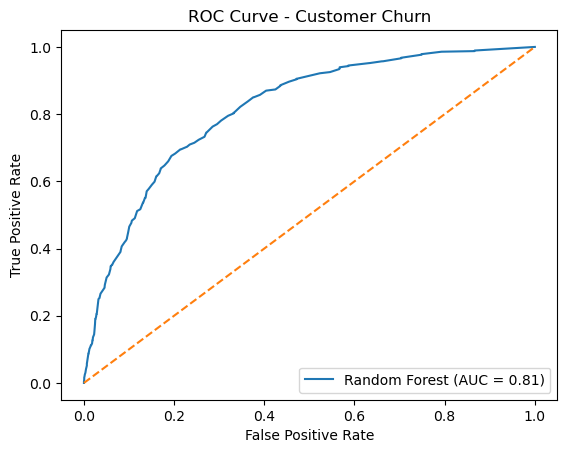

In [93]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# For Random Forest
fpr, tpr, thresholds = roc_curve(Y_test, rf_prob)
roc_auc = roc_auc_score(Y_test, rf_prob)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line (random model)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn")
plt.legend(loc="lower right")
plt.show()

I built a churn prediction model using Logistic Regression and Random Forest. Random Forest achieved higher ROC AUC. Feature importance showed that contract type, tenure, and monthly charges are top churn drivers. I tuned the threshold to improve recall since missing a churn customer is more costly than false alarms.